[OK] finetune_railsem_masked_density_nopretrain: 100 lignes | log = output_dir/finetune_thesis/finetune_railsem_masked_density_nopretrain/log.txt
[OK] finetune_railsem_masked_distance_nopretrain: 100 lignes | log = output_dir/finetune_thesis/finetune_railsem_masked_distance_nopretrain/log.txt
[OK] finetune_railsem_masked_position_nopretrain: 100 lignes | log = output_dir/finetune_thesis/finetune_railsem_masked_position_nopretrain/log.txt
[OK] finetune_railsem_nomask_nopretrain: 100 lignes | log = output_dir/finetune_thesis/finetune_railsem_nomask_nopretrain/log.txt


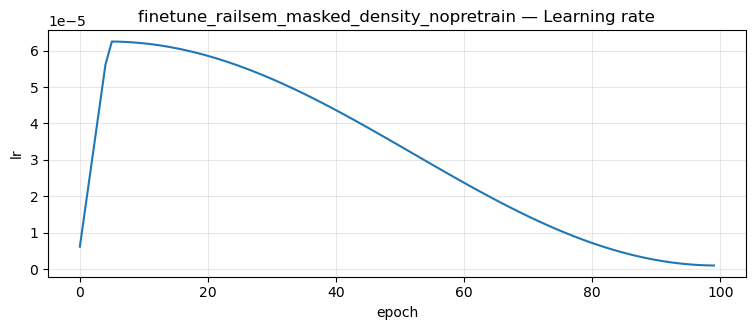

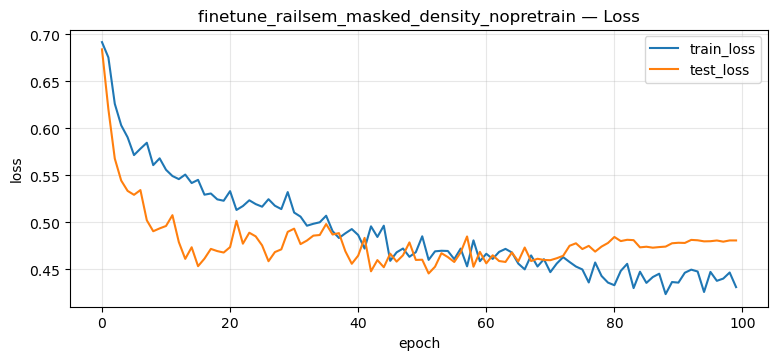

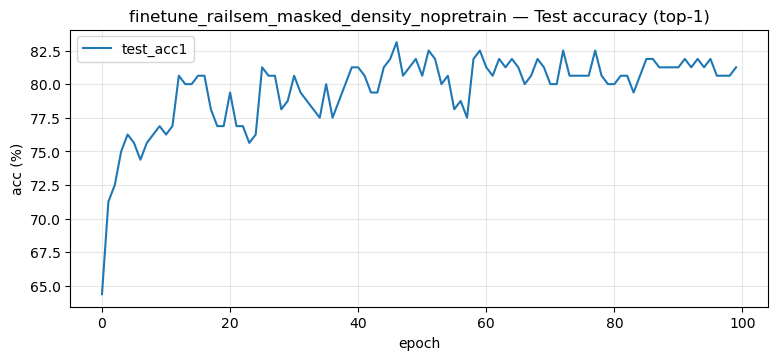

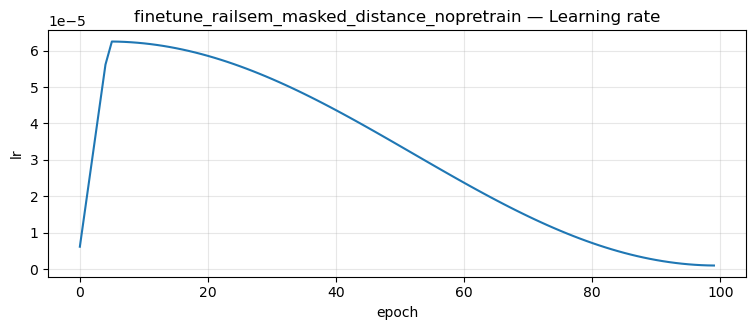

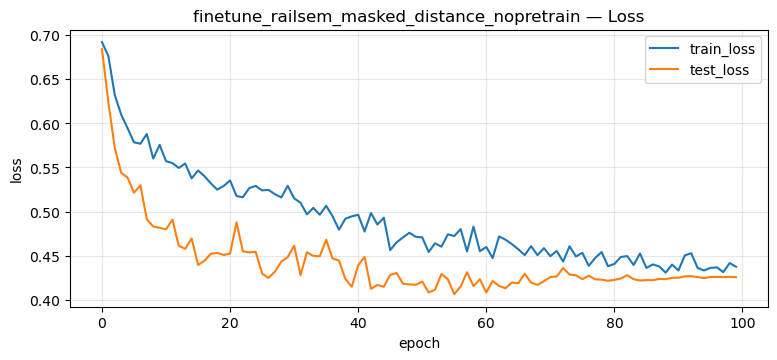

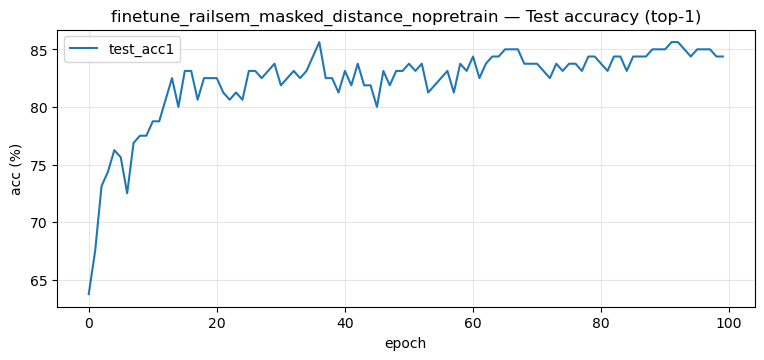

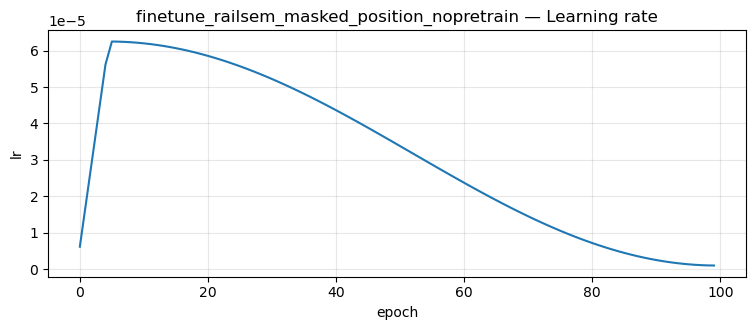

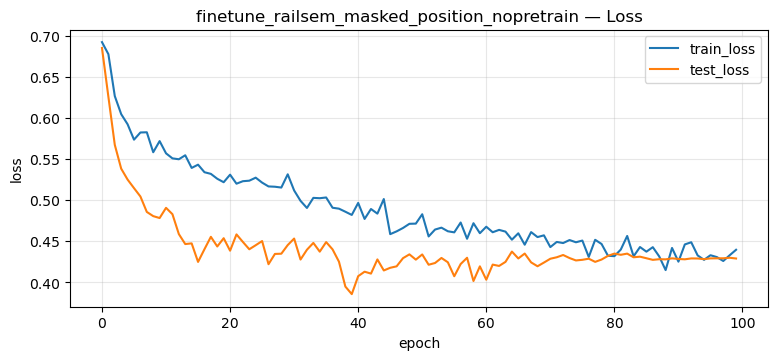

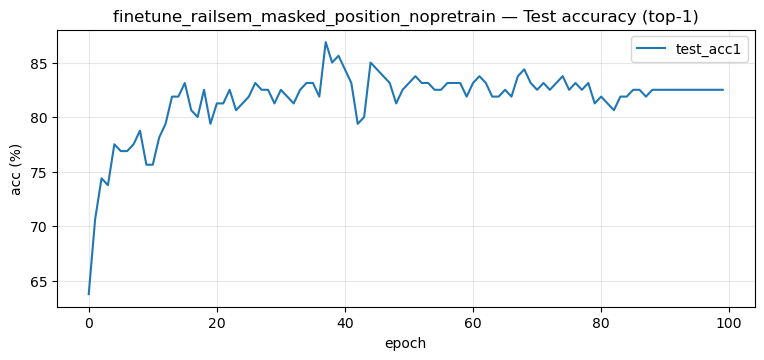

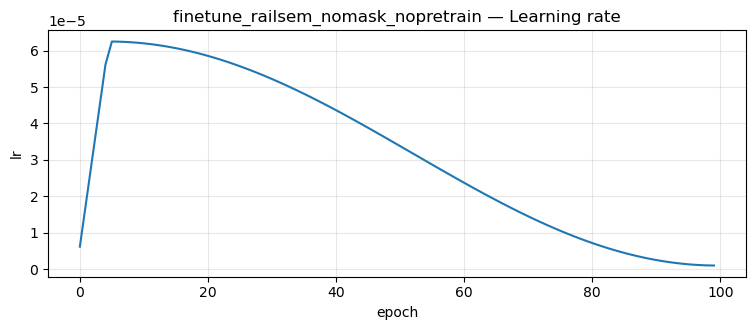

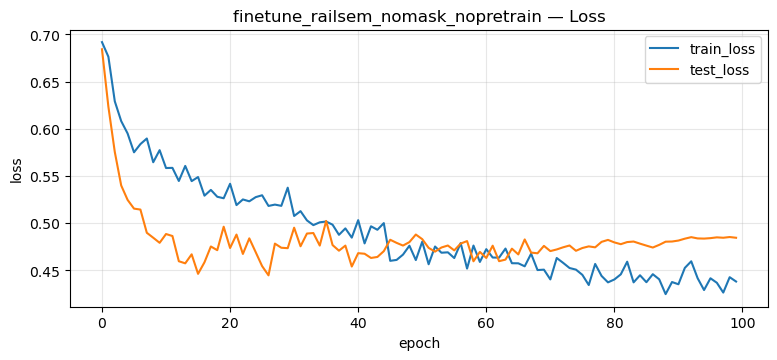

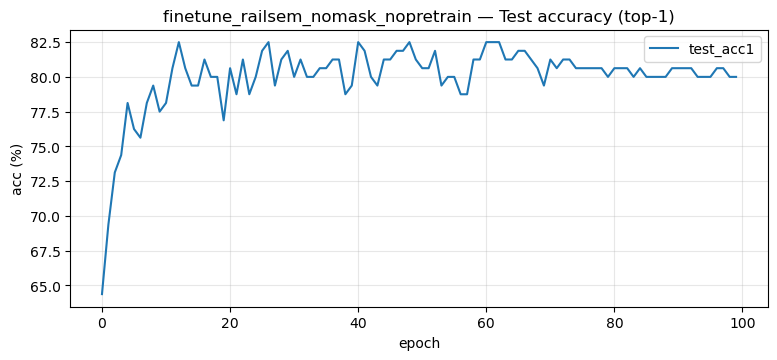

In [4]:
# Cellule unique "tout-en-un" :
# - cherche les 4 dossiers dans output_dir/finetune_thesis
# - trouve le log.txt (même dans sous-dossiers)
# - charge les lignes JSON/dict
# - affiche une vue "par modèle" : LR, Loss (train+test), Accuracy (acc1+acc5)

from pathlib import Path
import json
import ast
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("output_dir/finetune_thesis")

def _parse_line(line: str):
    line = line.strip()
    if not line:
        return None
    try:
        return json.loads(line)
    except Exception:
        try:
            return ast.literal_eval(line)  # fallback si dict python
        except Exception:
            return None

def read_log_file(log_path: Path) -> pd.DataFrame:
    rows = []
    for line in log_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        d = _parse_line(line)
        if isinstance(d, dict):
            rows.append(d)
    df = pd.DataFrame(rows)
    if not df.empty and "epoch" in df.columns:
        df = df.sort_values("epoch").reset_index(drop=True)
    return df

def find_logfile(model_dir: Path) -> Path | None:
    candidates = list(model_dir.glob("**/log.txt"))
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)  # plus récent
    return candidates[0]

def first_existing_col(df: pd.DataFrame, cols: list[str]) -> str | None:
    for c in cols:
        if c in df.columns:
            return c
    return None

def plot_one_model(name: str, df: pd.DataFrame):
    x = df["epoch"] if "epoch" in df.columns else range(len(df))

    lr_c   = first_existing_col(df, ["train_lr", "lr", "learning_rate"])
    tr_c   = first_existing_col(df, ["train_loss", "loss", "train/loss"])
    te_c   = first_existing_col(df, ["test_loss", "val_loss", "eval_loss", "test/loss"])
    acc1_c = first_existing_col(df, ["test_acc1", "acc1", "top1", "test/top1"])
    #acc5_c = first_existing_col(df, ["test_acc5", "acc5", "top5", "test/top5"])

    # LR
    if lr_c is not None:
        plt.figure(figsize=(9, 3.2))
        plt.plot(x, df[lr_c])
        plt.title(f"{name} — Learning rate")
        plt.xlabel("epoch")
        plt.ylabel("lr")
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"[{name}] pas de colonne LR trouvée")

    # Losses
    if (tr_c is not None) or (te_c is not None):
        plt.figure(figsize=(9, 3.6))
        if tr_c is not None:
            plt.plot(x, df[tr_c], label="train_loss")
        if te_c is not None:
            plt.plot(x, df[te_c], label="test_loss")
        plt.title(f"{name} — Loss")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    else:
        print(f"[{name}] pas de colonnes loss trouvées")

        # --- Accuracy (top-1 uniquement) ---
    if acc1_c is not None:
        plt.figure(figsize=(9, 3.6))
        plt.plot(x, df[acc1_c], label="test_acc1")
        plt.title(f"{name} — Test accuracy (top-1)")
        plt.xlabel("epoch")
        plt.ylabel("acc (%)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    else:
        print(f"[{name}] pas de colonne accuracy top-1 trouvée")



# -------- MAIN --------
if not ROOT.exists():
    raise FileNotFoundError(f"Dossier introuvable: {ROOT.resolve()}")

model_dirs = [p for p in ROOT.iterdir() if p.is_dir()]

logs: dict[str, pd.DataFrame] = {}
for md in sorted(model_dirs):
    lf = find_logfile(md)
    if lf is None:
        print(f"[WARN] Pas de log.txt trouvé dans {md.name}")
        continue
    df = read_log_file(lf)
    if df.empty:
        print(f"[WARN] log.txt vide / illisible pour {md.name}: {lf}")
        continue
    logs[md.name] = df
    print(f"[OK] {md.name}: {len(df)} lignes | log = {lf}")

if not logs:
    raise RuntimeError("Aucun log chargé. Vérifie la structure des dossiers / log.txt.")

# Vue par modèle
for name, df in logs.items():
    plot_one_model(name, df)


[OK] railsem_masked_density_nopretrained: 500 lignes | log = output_dir/pretrain_thesis/railsem_masked_density_nopretrained/log.txt
[OK] railsem_masked_distance_nopretrained: 500 lignes | log = output_dir/pretrain_thesis/railsem_masked_distance_nopretrained/log.txt
[OK] railsem_masked_position_nopretrain: 500 lignes | log = output_dir/pretrain_thesis/railsem_masked_position_nopretrain/log.txt
[OK] railsem_nomasked_nopretrain: 500 lignes | log = output_dir/pretrain_thesis/railsem_nomasked_nopretrain/log.txt


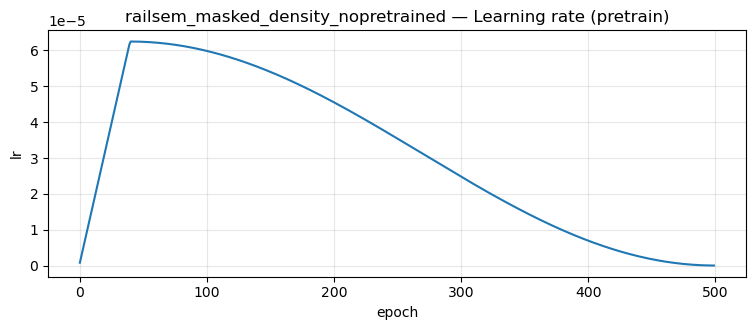

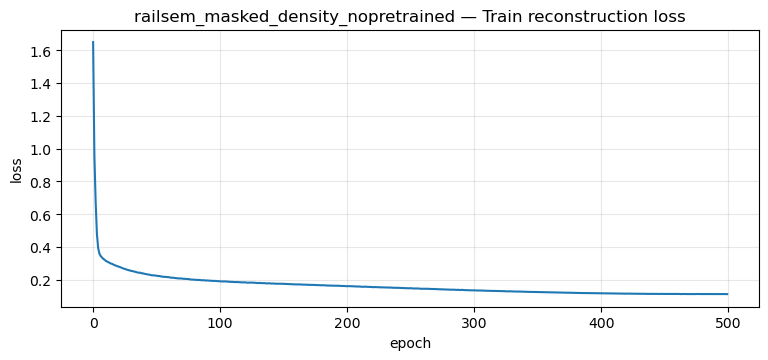

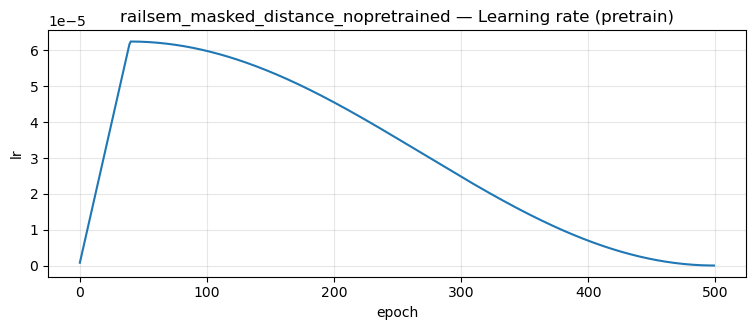

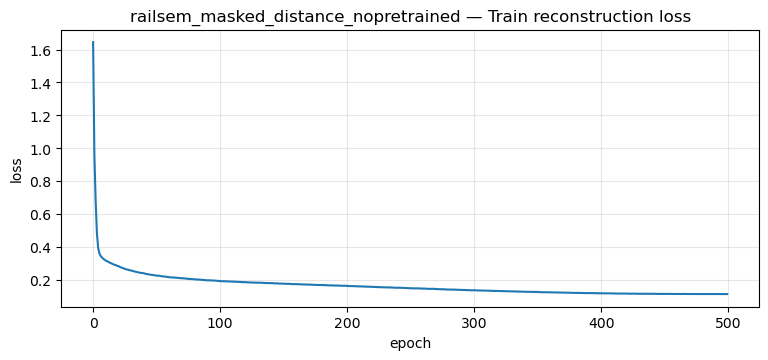

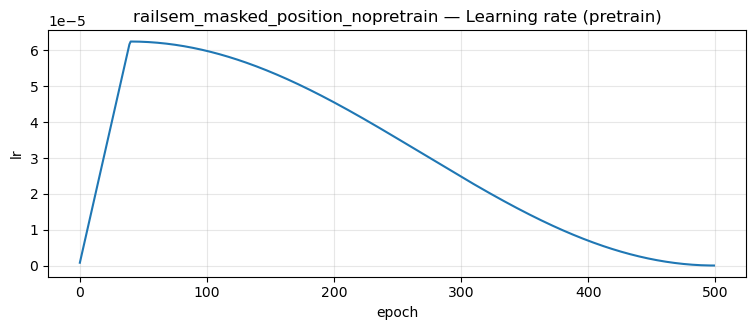

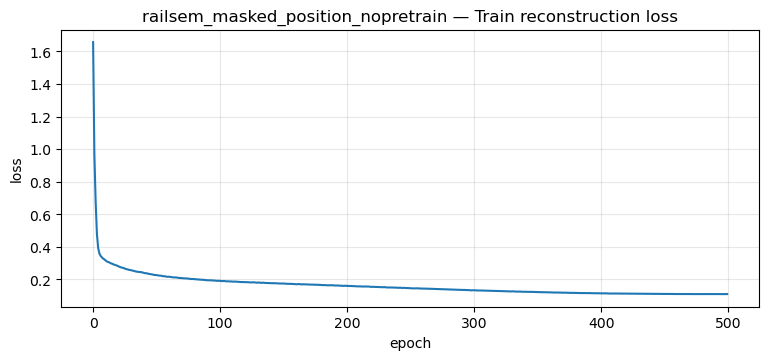

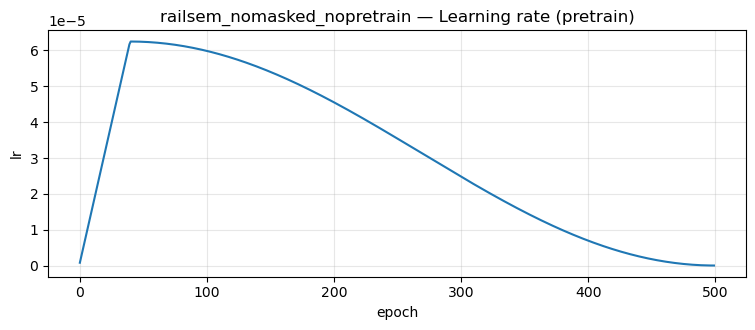

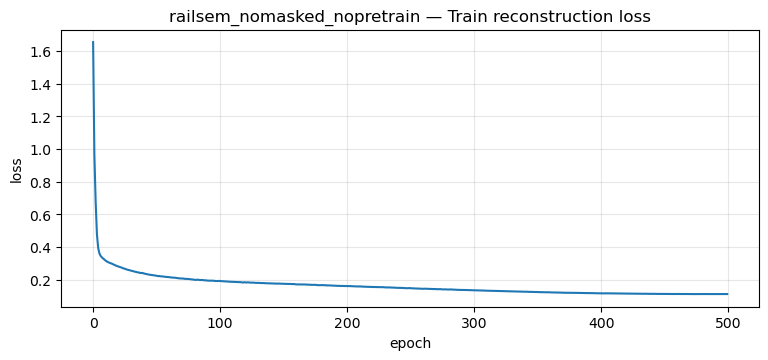

In [5]:
# Cellule unique "tout-en-un" pour PRETRAIN :
# - cherche les dossiers dans output_dir/pretrain_thesis
# - trouve le log.txt (même dans sous-dossiers)
# - charge les lignes {"train_lr": ..., "train_loss": ..., "epoch": ...}
# - affiche une vue "par modèle" : LR + Train reconstruction loss

from pathlib import Path
import json
import ast
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("output_dir/pretrain_thesis")

def _parse_line(line: str):
    line = line.strip()
    if not line:
        return None
    try:
        return json.loads(line)
    except Exception:
        try:
            return ast.literal_eval(line)  # fallback si dict python
        except Exception:
            return None

def read_log_file(log_path: Path) -> pd.DataFrame:
    rows = []
    for line in log_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        d = _parse_line(line)
        if isinstance(d, dict):
            rows.append(d)
    df = pd.DataFrame(rows)
    if not df.empty and "epoch" in df.columns:
        df = df.sort_values("epoch").reset_index(drop=True)
    return df

def find_logfile(model_dir: Path) -> Path | None:
    candidates = list(model_dir.glob("**/log.txt"))
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)  # plus récent
    return candidates[0]

def first_existing_col(df: pd.DataFrame, cols: list[str]) -> str | None:
    for c in cols:
        if c in df.columns:
            return c
    return None

def plot_one_model_pretrain(name: str, df: pd.DataFrame):
    x = df["epoch"] if "epoch" in df.columns else range(len(df))

    lr_c = first_existing_col(df, ["train_lr", "lr", "learning_rate"])
    loss_c = first_existing_col(df, ["train_loss", "loss", "recon_loss", "reconstruction_loss"])

    # LR
    if lr_c is not None:
        plt.figure(figsize=(9, 3.2))
        plt.plot(x, df[lr_c])
        plt.title(f"{name} — Learning rate (pretrain)")
        plt.xlabel("epoch")
        plt.ylabel("lr")
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"[{name}] pas de colonne LR trouvée")

    # Train reconstruction loss
    if loss_c is not None:
        plt.figure(figsize=(9, 3.6))
        plt.plot(x, df[loss_c])
        plt.title(f"{name} — Train reconstruction loss")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"[{name}] pas de colonne train_loss trouvée")


# -------- MAIN --------
if not ROOT.exists():
    raise FileNotFoundError(f"Dossier introuvable: {ROOT.resolve()}")

model_dirs = [p for p in ROOT.iterdir() if p.is_dir()]

logs_pretrain: dict[str, pd.DataFrame] = {}
for md in sorted(model_dirs):
    lf = find_logfile(md)
    if lf is None:
        print(f"[WARN] Pas de log.txt trouvé dans {md.name}")
        continue
    df = read_log_file(lf)
    if df.empty:
        print(f"[WARN] log.txt vide / illisible pour {md.name}: {lf}")
        continue
    logs_pretrain[md.name] = df
    print(f"[OK] {md.name}: {len(df)} lignes | log = {lf}")

if not logs_pretrain:
    raise RuntimeError("Aucun log chargé. Vérifie la structure des dossiers / log.txt.")

# Vue par modèle
for name, df in logs_pretrain.items():
    plot_one_model_pretrain(name, df)
